# YOLO Segmentation Inference
3개 클래스(DOOR, JOG, MEMORY)에 대한 인스턴스 세그멘테이션 추론

In [1]:
from ultralytics import YOLO
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# 모델 경로
MODEL_PATH = '/data/th/KETI/Grounded-SAM-2/trained_models/yolo_seg_20251121_055950/weights/best.pt'

# 모델 로드
model = YOLO(MODEL_PATH)

# 클래스 정보
classes = {0: 'DOOR', 1: 'JOG', 2: 'MEMORY'}

print(f"모델 로드 완료: {MODEL_PATH}")
print(f"클래스: {classes}")

모델 로드 완료: /data/th/KETI/Grounded-SAM-2/trained_models/yolo_seg_20251121_055950/weights/best.pt
클래스: {0: 'DOOR', 1: 'JOG', 2: 'MEMORY'}


In [2]:
# 세그멘테이션 추론 및 시각화 함수
def predict_segmentation(image_path, conf=0.5):
    """
    이미지에서 세그멘테이션을 수행하고 시각화
    
    Args:
        image_path: 이미지 파일 경로
        conf: 신뢰도 임계값 (0.0 ~ 1.0)
    """
    # 이미지 로드
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"이미지를 로드할 수 없습니다: {image_path}")
        return
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 추론 수행
    results = model.predict(image_path, conf=conf, verbose=False)
    result = results[0]
    
    # 결과 시각화
    annotated_frame = result.plot()
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    
    # 탐지된 객체 정보 출력
    print(f"\n이미지: {Path(image_path).name}")
    print(f"탐지된 객체 수: {len(result.boxes)}")
    
    if result.masks is not None:
        for idx, (box, mask) in enumerate(zip(result.boxes, result.masks)):
            class_id = int(box.cls[0].item())
            class_name = classes[class_id]
            confidence = box.conf[0].item()
            coords = box.xyxy[0].tolist()
            
            print(f"  {idx+1}. {class_name} (신뢰도: {confidence:.2%})")
            print(f"     위치: x1={coords[0]:.1f}, y1={coords[1]:.1f}, x2={coords[2]:.1f}, y2={coords[3]:.1f}")
            print(f"     마스크 크기: {mask.xy[0].shape}")
    else:
        for idx, box in enumerate(result.boxes):
            class_id = int(box.cls[0].item())
            class_name = classes[class_id]
            confidence = box.conf[0].item()
            coords = box.xyxy[0].tolist()
            
            print(f"  {idx+1}. {class_name} (신뢰도: {confidence:.2%})")
            print(f"     위치: x1={coords[0]:.1f}, y1={coords[1]:.1f}, x2={coords[2]:.1f}, y2={coords[3]:.1f}")
    
    # 이미지 표시
    plt.figure(figsize=(14, 10))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


이미지: 5_on.jpg
탐지된 객체 수: 2
  1. JOG (신뢰도: 87.23%)
     위치: x1=1320.1, y1=382.1, x2=1369.4, y2=428.8
     마스크 크기: (8, 2)
  2. MEMORY (신뢰도: 71.72%)
     위치: x1=1199.6, y1=374.0, x2=1248.9, y2=421.1
     마스크 크기: (11, 2)


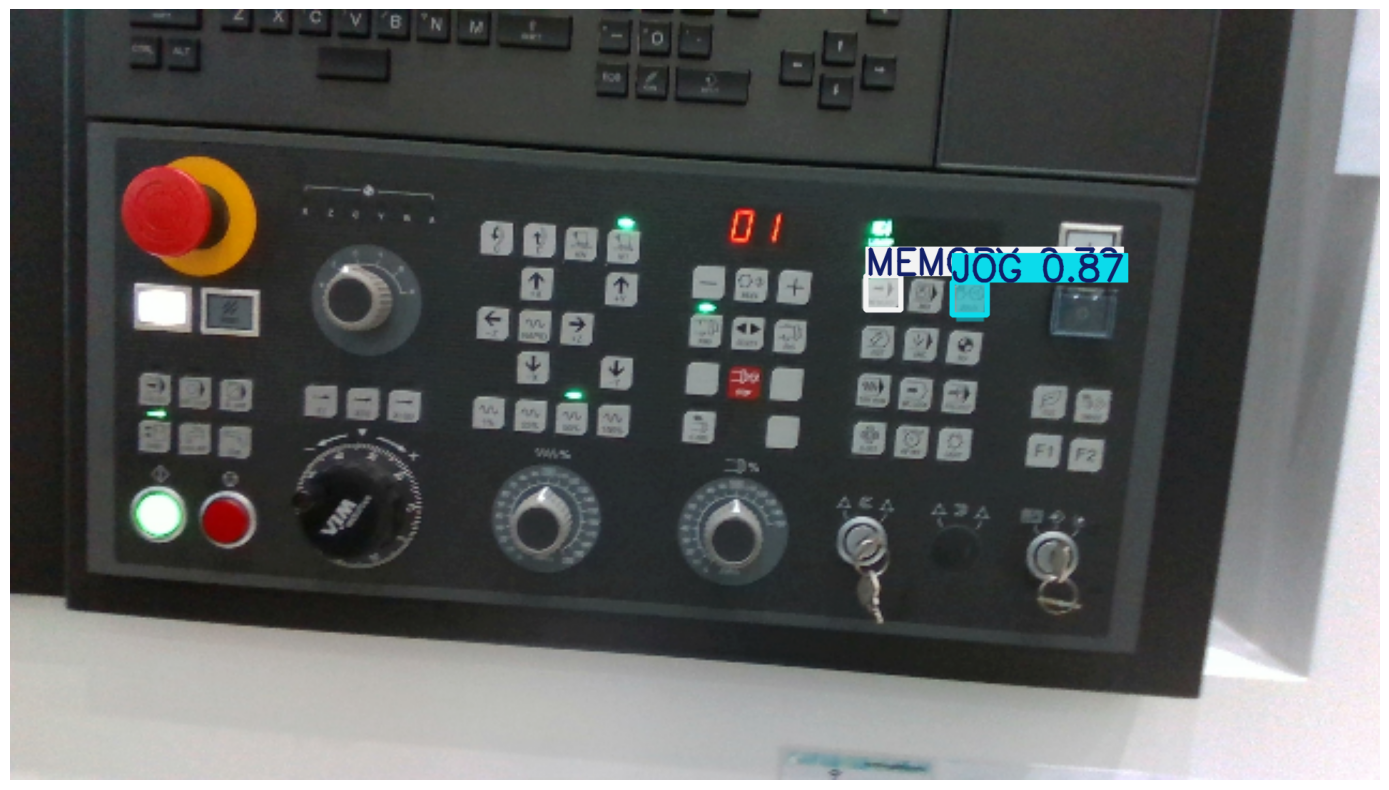

In [4]:
# 추론 실행
# 이미지 파일 경로를 지정하세요
image_path = '../images/5_on.jpg'  # 추론할 이미지 경로를 지정

# 신뢰도 임계값 설정 (기본값: 0.5)
confidence_threshold = 0.5

predict_segmentation(image_path, conf=confidence_threshold)